In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [3]:
data=pd.read_csv("ID3.csv")
print("Dataset:")
display(data)


Dataset:


,Day,Outlook,Temperature,Humidity,Wind,Play
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Cloudy,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes
5,6,Rain,Cool,Normal,Strong,No
6,7,Cloudy,Cool,Normal,Strong,Yes
7,8,Sunny,Mild,High,Weak,No
8,9,Sunny,Cool,Normal,Weak,Yes
9,10,Rain,Mild,Normal,Weak,Yes


In [4]:
data=data.drop(columns=["Day"])

In [5]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]
print("Features:")
display(x)
print("Target:")
display(y)

Features:


,Outlook,Temperature,Humidity,Wind
0,Sunny,Hot,High,Weak
1,Sunny,Hot,High,Strong
2,Cloudy,Hot,High,Weak
3,Rain,Mild,High,Weak
4,Rain,Cool,Normal,Weak
5,Rain,Cool,Normal,Strong
6,Cloudy,Cool,Normal,Strong
7,Sunny,Mild,High,Weak
8,Sunny,Cool,Normal,Weak
9,Rain,Mild,Normal,Weak


Target:


0      No
1      No
2     Yes
3     Yes
4     Yes
5      No
6     Yes
7      No
8     Yes
9     Yes
10    Yes
11    Yes
12    Yes
13     No
Name: Play, dtype: object

In [6]:
def entropy(target_col):
    values,counts=np.unique(target_col,return_counts=True)
    entropy_value=0

    for i in range(len(values)):
        probability=counts[i] / np.sum(counts)
        entropy_value+= -probability * math.log2(probability)

    return entropy_value
    

In [7]:
total_entropy=entropy(y)
print(f"entropy of target playTennis:{total_entropy:.4f}")

entropy of target playTennis:0.9403


In [8]:
def information_gain(data, split_attribute, target_name):
    total_entropy = entropy(data[target_name])

    values, counts = np.unique(data[split_attribute], return_counts=True)

    weighted_entropy = 0
    for i in range(len(values)):
        subset = data[data[split_attribute] == values[i]]
        subset_entropy = entropy(subset[target_name])
        weighted_entropy += (counts[i] / np.sum(counts)) * subset_entropy

    IG = total_entropy - weighted_entropy

    return IG


print("Information Gain of each attribute:\n")

for feature in x.columns:
    ig = information_gain(data, feature, y.name)
    print(f"IG({feature}) = {ig:.4f}")

Information Gain of each attribute:

IG(Outlook) = 0.2467
IG(Temperature) = 0.0292
IG(Humidity) = 0.1518
IG(Wind) = 0.0481


In [9]:
IG_values = {feature:information_gain(data, feature, y.name) for feature in x.columns}
root_node=max(IG_values,key=IG_values.get)
print("\nRoot Node (Highest Information Gain):")
print(root_node)


Root Node (Highest Information Gain):
Outlook


In [10]:
print(f"\nChild nodes for root attributs '(root_node)':")
for value in data[root_node].unique():
    subset=data[data[root_node]==value]
    print(f"\n{root_node}={value}")
    display(subset)


Child nodes for root attributs '(root_node)':

Outlook=Sunny


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
10,Sunny,Mild,Normal,Strong,Yes



Outlook=Cloudy


,Outlook,Temperature,Humidity,Wind,Play
2,Cloudy,Hot,High,Weak,Yes
6,Cloudy,Cool,Normal,Strong,Yes
11,Cloudy,Mild,High,Strong,Yes
12,Cloudy,Hot,Normal,Weak,Yes



Outlook=Rain


,Outlook,Temperature,Humidity,Wind,Play
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
9,Rain,Mild,Normal,Weak,Yes
13,Rain,Mild,High,Strong,No


In [11]:
encoder=LabelEncoder()
encoded_data=data.copy()
for column in encoded_data.columns:
    encoded_data[column]=encoder.fit_transform(encoded_data[column])
display(encoded_data)

,Outlook,Temperature,Humidity,Wind,Play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [12]:
x_encoded= encoded_data.iloc[:,:-1]
y_encoded= encoded_data.iloc[:, -1]
model=DecisionTreeClassifier(criterion="entropy")
model.fit(x_encoded,y_encoded)
print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


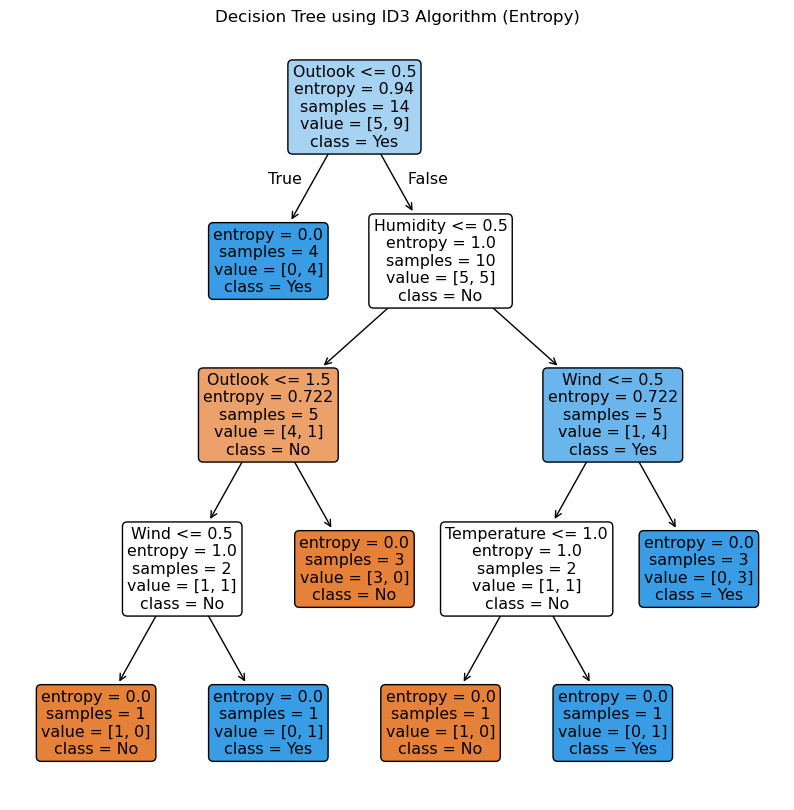

In [13]:
plt.figure(figsize=(10,10))
plot_tree(
    model,
    feature_names=x.columns.tolist(),
    class_names=[str(c) for c in np.unique(y)],
    filled=True,
    rounded=True
)
plt.title("Decision Tree using ID3 Algorithm (Entropy)")
plt.show()